# ML System design

## A/B Testing.

In this notebook, we will learn how to verify the correctness of A/B test design.

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from tqdm import tqdm

Let’s assume we have an online store. Every week, users make purchases.

### We will generate a dataset:

Suppose we have data from 100 weeks for 10,000 customers.

In [ ]:
weeks = [x + 1 for x in range(100)]

Each customer has their own behavior — for example, a certain average spending level.

In [ ]:
np.random.seed(24)
client_means = np.random.normal(loc=100, scale=40, size=10000)

We will construct a dataset where each customer brings us a certain amount of profit each week, based on their individual behavior.

In [ ]:
client_dfs = []
for n, m in enumerate(client_means):
  np.random.seed(n)
  client_df = pd.DataFrame({'week': weeks, 'client_id': n, 'revenue': np.random.normal(loc=m, scale=5, size=100)})
  client_dfs.append(client_df)

In [ ]:
client_data = pd.concat(client_dfs)

In [ ]:
client_data.head()

,week,client_id,revenue
0,1,0,161.988749
1,2,0,155.169273
2,3,0,158.062177
3,4,0,164.372953
4,5,0,162.506277


### Designing the experiment

We’ll estimate the required group size using a formula:

$$
N = \frac{2\sigma^2 (Z_{1 - \alpha} + Z_{1 - \beta})^2}{\varepsilon^2}
$$

https://medium.com/data-science/probing-into-minimum-sample-size-formula-derivation-and-usage-8db9a556280b


In [ ]:
def estimate_sample_size(effect, std, alpha, beta):
    """Required group size."""
    t_alpha = stats.norm.ppf(1 - alpha / 2, loc=0, scale=1)
    t_beta = stats.norm.ppf(1 - beta, loc=0, scale=1)
    var = 2 * std ** 2
    sample_size = int((t_alpha + t_beta) ** 2 * var / (effect ** 2))
    return sample_size

This formula can be used when the distribution is approximately normal and not heavily skewed.
Let’s pick a random week, look at the distribution, and estimate the variance.

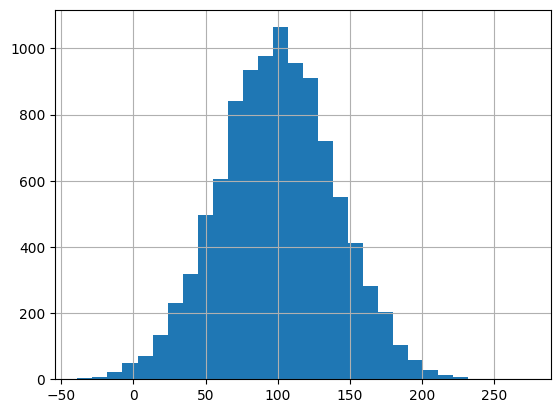

In [ ]:
client_data[client_data.week==5].revenue.hist(bins=30);

In [ ]:
estimated_std = client_data[client_data.week==5].revenue.std()
estimated_std

39.93403686526723

In [ ]:
alpha = 0.05
beta = 0.2
effect = 5
sample_size = estimate_sample_size(effect, estimated_std, alpha, beta)
print(f'Estimating required group size = {sample_size}')

Estimating required group size = 1001


### Let's check the validity of our experiment.

**What does it mean for a test to be valid (correct)?**

It means that we are controlling the Type I and Type II error rates.

**How do we check that?**

**Type I error**: We will run many AA tests on historical data, following our test design.
We know that in the historical data, nothing actually affected the groups.
So the test should not show any statistically significant differences.
Then, we will calculate the proportion of times the test did detect a difference — this should correspond to our test’s significance level.

**Type II error**: We will do the same, but artificially introduce an effect into group B.
This time, we will measure how often the test fails to detect statistically significant differences between the groups.

In [ ]:
def run_test(n_users, effect, iter_num):
  p_values_aa = []
  p_values_ab = []

  all_weeks = client_data['week'].unique()

  for _ in tqdm(range(iter_num)):
    # 1. Randomly select one historical week
    week = np.random.choice(all_weeks)
    week_data = client_data[client_data['week'] == week]

    # 2. Randomly sample two independent groups of users
    users = week_data['client_id'].unique()
    sampled_users = np.random.choice(users, size=n_users * 2, replace=False)
    group_a_users = sampled_users[:n_users]
    group_b_users = sampled_users[n_users:]

    group_a = week_data[week_data['client_id'].isin(group_a_users)]['revenue'].values
    group_b = week_data[week_data['client_id'].isin(group_b_users)]['revenue'].values

    # 3. A/A test (no effect added)
    _, p_aa = stats.ttest_ind(group_a, group_b)
    p_values_aa.append(p_aa)

    # A/B test (add artificial effect to group B)
    group_b_ab = group_b + effect
    _, p_ab = stats.ttest_ind(group_a, group_b_ab)
    p_values_ab.append(p_ab)

  return p_values_aa, p_values_ab

In [ ]:
p_values_aa,  p_values_ab = run_test(sample_size, effect, 1000)

In [ ]:
# empirical Type I error rate
empirical_type1_error = (pd.Series(p_values_aa) < alpha).mean()
print(f'Empirical Type I error rate: {empirical_type1_error:.3f}  (target alpha={alpha})')

In [ ]:
# empirical Type II error rate
empirical_type2_error = (pd.Series(p_values_ab) >= alpha).mean()
print(f'Empirical Type II error rate: {empirical_type2_error:.3f}  (target beta={beta})')

In [ ]:
import matplotlib.pyplot as plt

def plot_pvalue_distribution(pvalues_aa, pvalues_ab, alpha, beta):
    """Plots the Cumulative Distribution Function (CDF)."""
    estimated_first_type_error = np.mean(pvalues_aa < alpha)
    estimated_second_type_error = np.mean(pvalues_ab >= alpha)
    y_one = estimated_first_type_error
    y_two = 1 - estimated_second_type_error
    X = np.linspace(0, 1, 1000)
    Y_aa = [np.mean(pvalues_aa < x) for x in X]
    Y_ab = [np.mean(pvalues_ab < x) for x in X]

    plt.plot(X, Y_aa, label='A/A')
    plt.plot(X, Y_ab, label='A/B')
    plt.plot([alpha, alpha], [0, 1], '--k', alpha=0.8)
    plt.plot([0, alpha], [y_one, y_one], '--k', alpha=0.8)
    plt.plot([0, alpha], [y_two, y_two], '--k', alpha=0.8)
    plt.plot([0, 1], [0, 1], '--k', alpha=0.8)

    plt.title('CDF of p-values', size=16)
    plt.xlabel('p-value', size=12)
    plt.legend(fontsize=12)
    plt.grid()
    plt.show()

In [ ]:
plot_pvalue_distribution(pd.Series(p_values_aa), pd.Series(p_values_ab), alpha, beta)

**What is this curve?**

This is a CDF — Cumulative Distribution Function of p-values from our simulated experiments.

**X-axis**: possible p-values (from 0 to 1)

**Y-axis**: what fraction of p-values were less than or equal to X

So at each point X, the curve shows:
**“In how many experiments was p-value ≤ X?”**


**If the curve follows the diagonal line y = x**, it means that p-values are uniformly distributed — as expected under the null hypothesis (e.g., in A/A tests).

**If the curve rises above the diagonal**, it means there are more small p-values than expected — so we’re rejecting the null hypothesis more often, as we would in A/B tests with a real effect.

### Let’s design another experiment

Suppose we’re told that our test requires too many users, and we need to reduce the sample size.
So we decide to change the unit of randomization: instead of individual users, we’ll use user + week as the unit.
We’ll run the test for two weeks, and include half as many users!

Is this approach valid?

Even if you're not confident about the answer — maybe because it's been a while since you studied statistics —
you can easily test this idea using historical data!

In [ ]:
def run_test_II(n_users, effect, iter_num):
  p_values_aa = []
  p_values_ab = []

  all_weeks = sorted(client_data['week'].unique())
  n_users_half = n_users // 2  # half as many users, but observed over two weeks

  for _ in tqdm(range(iter_num)):
    # 1. Randomly select a week (not the last one, since we need week+1)
    week = np.random.choice(all_weeks[:-1])
    next_week = week + 1

    week_data = client_data[client_data['week'] == week]

    # 2. Randomly sample n_users_half users; pull their data for both weeks
    users = week_data['client_id'].unique()
    sampled_users = np.random.choice(users, size=n_users_half * 2, replace=False)
    group_a_users = sampled_users[:n_users_half]
    group_b_users = sampled_users[n_users_half:]

    two_week_data = client_data[client_data['week'].isin([week, next_week])]

    group_a = two_week_data[two_week_data['client_id'].isin(group_a_users)]['revenue'].values
    group_b = two_week_data[two_week_data['client_id'].isin(group_b_users)]['revenue'].values

    # 3. A/A test (no effect)
    _, p_aa = stats.ttest_ind(group_a, group_b)
    p_values_aa.append(p_aa)

    # A/B test (add artificial effect to group B)
    group_b_ab = group_b + effect
    _, p_ab = stats.ttest_ind(group_a, group_b_ab)
    p_values_ab.append(p_ab)

  return p_values_aa, p_values_ab

In [ ]:
p_values_aa,  p_values_ab = run_test_II(sample_size, effect, 1000)

Type I and Type II error rate

In [ ]:
(pd.Series(p_values_aa) < alpha).mean().item(), (pd.Series(p_values_ab) >= alpha).mean().item()

In [ ]:
plot_pvalue_distribution(pd.Series(p_values_aa), pd.Series(p_values_ab), alpha, beta)

We can see that in the A/A tests, the CDF curve moved noticeably above the diagonal.
This tells us that the test is no longer working correctly — it finds too many small p-values, even when there’s no real difference.

Why is that happening?
Because we changed the unit to user + week, which means the same users appear more than once.
The t-test assumes that all observations are independent — and that’s no longer true.
As a result, the test becomes biased and unreliable.

